In [1]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there

In [2]:
score_loc = '../raw_scores/ligand'
scores = pd.concat([pd.read_csv(f'{score_loc}/{target}.RESULTS') for target in ['D1273','R1288','R1261v1','R1262v1']])

# R1262 not in ranking

In [3]:
native_half_scores = {'R1263':{'A': [0.196728,0.583062], 'B':[0.256678,0.416938]},
                      'R1264':{'A': [0.134906,0.598716], 'B':[0.315583,0.401284]}}

for target in ['R1263','R1264']:
    dimer_df = pd.read_csv(f'{score_loc}/{target}v1_dimer.RESULTS')
    A_df = pd.read_csv(f'{score_loc}/{target}v1A.RESULTS')
    B_df = pd.read_csv(f'{score_loc}/{target}v1B.RESULTS')

    # check ordering
    if not ( dimer_df.model.equals( A_df.model) and dimer_df.model.equals( B_df.model) ):
        print('errro')
    dimer_scores = dimer_df[['lddt_lp','lddt_pli']]
    chain_A_scores = A_df[['lddt_lp','lddt_pli']] 
    chain_B_scores = B_df[['lddt_lp','lddt_pli']]

    # get which chain they had the best score for -- this is the pocket they modeled -- will normalize their dimer score
    max_monomer_scores = np.maximum(chain_A_scores,chain_B_scores)
    chain_A_best = max_monomer_scores == chain_A_scores

    # normalize the dimer score
    models = dimer_df[['model','group','target']]
    multiplier = dimer_scores.copy()
    multiplier[np.array(chain_A_best)] = native_half_scores[target]['A']
    multiplier[np.array(~chain_A_best)] = native_half_scores[target]['B']
    new_ligand = pd.concat([models.reset_index(),(dimer_scores.reset_index()/multiplier.reset_index())],axis=1)
    renormalized_lddpt_lp = new_ligand.set_index('model').lddt_lp.to_dict()
    renormalized_lddt_pli = new_ligand.set_index('model').lddt_pli.to_dict()
    dimer_df['lddt_lp_dimer'] = dimer_df.lddt_lp.copy()
    dimer_df['lddt_pli_dimer'] = dimer_df.lddt_pli.copy()
    dimer_df['lddt_lp'] = dimer_df.model.map(renormalized_lddpt_lp)
    dimer_df['lddt_pli'] = dimer_df.model.map(renormalized_lddt_pli)

    scores = pd.concat([scores,dimer_df]).reset_index()

In [4]:
scores['group'] = scores.group.apply(lambda x: "0"*(3-len(str(x)))+str(x))
scores['gr_code'] = scores.group.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)
scores.head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
0,0,0.0,D1273,338,D1273LG338_3,model_tmp.sdf,0.182770,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,5.832458,0.291972,6.921857,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,GeneSilico - 338
1,1,1.0,D1273,294,D1273LG294_4,model_tmp.sdf,0.163571,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,7.624604,0.313891,7.104760,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
2,2,2.0,D1273,294,D1273LG294_1,model_tmp.sdf,0.161367,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,9.253408,0.276949,7.384906,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
3,3,3.0,D1273,294,D1273LG294_2,model_tmp.sdf,0.154391,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,8.129498,0.365423,6.923060,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
4,4,4.0,D1273,294,D1273LG294_3,model_tmp.sdf,0.153204,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,7.305310,0.291372,7.815579,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294


In [5]:
scores.to_csv('summary_tables/ligand.csv',index=False)

In [6]:
scores.group.unique()

array(['338', '294', '262', '055', '091', '207', '408', '464', '063',
       '272'], dtype=object)

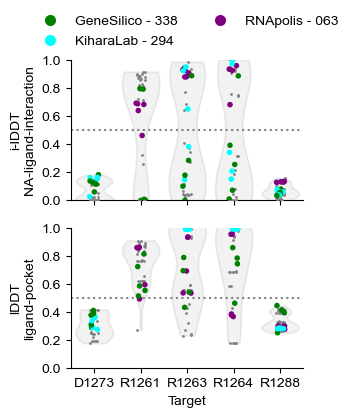

In [7]:
metrics_to_plot = ['lddt_pli', 'lddt_lp']#,'rmsd']#, 'bb_rmsd']

fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,2*len(metrics_to_plot)),sharex=True)
labels = {'lddt_pli':'i-lDDT\nNA-ligand-interaction','rmsd':'RMSD\nligand-pocket',
          'lddt_lp':'lDDT\nligand-pocket','bb_rmsd':"backbone (C3') RMSD ligand-pocket"}
for i,metric in enumerate(metrics_to_plot):
    #duplicates = scores.groupby(['target', metric]).filter(lambda x: len(x) > 1)
    sns.violinplot(scores,x='target',y=metric,color='grey',inner=None,ax=axes[i],
                   alpha=0.1,density_norm='width',cut=0,order=LIGAND_TARGETS)
    g=sns.stripplot(scores[~scores.gr_code.isin(GROUP_HIGHLIGHTS.keys())],x='target',
                    y=metric,size=2, color='grey',ax=axes[i],order=LIGAND_TARGETS)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(scores[scores.gr_code.isin(GROUP_HIGHLIGHTS.keys())],x='target',
                    y=metric,size=4, hue='gr_code',palette=GROUP_HIGHLIGHTS,ax=axes[i],
                    order=LIGAND_TARGETS,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_xticks(g.get_xticks())
    g.set_ylabel(labels[metric])
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 0,size=10)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=2, title=None, frameon=False,markerscale=2)
t=axes[-1].set_xticklabels(LIGAND_TARGETS,rotation=0)
plt.savefig("figure_subpanels/ligand_all_scores.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/ligand_all_scores.svg",dpi=400, bbox_inches='tight', transparent=True)

In [8]:
# reduce to one (best) score per group per target
columns = ['target', 'gr_code']
best1_df_ligand = reduce_df(scores, score_to_choice_best=None,
               static_columns=columns, metric_dict=LIGAND_METRICS,
                           participipation_cutoff=PARTICIPATION_RATE,participation_score='lddt_pli',
              participation_targets=LIGAND_TARGETS)

# on the one model per group per target, calculate Z-scores for each metric
temp_dfs = []
for target in LIGAND_TARGETS:
    #print(target)
    target_df = best1_df_ligand[best1_df_ligand.target==target].copy()
    #print(target_df.columns)
    for metric in LIGAND_METRICS.keys():
        #print(target_df[metric])
        #print(metric)
        if ('inf' in metric and target in ['D1273','R1286']) or (metric == 'clashscore' and target in ['R1286']):
            target_df["Z_"+metric] = 0
        else:
            target_df["Z_"+metric] = get_zscore(target_df[metric].to_numpy(copy=True),
                                            negative=(LIGAND_METRICS[metric]=="min"),
                                            tolerance_threshold=-2,
                                           penalty_threshold=None)
    temp_dfs.append(target_df)
best1_df_ligand = pd.concat(temp_dfs,ignore_index=True)

# get weighted Zs
for name,score_wieghts in LIGAND_SCORES.items():
    best1_df_ligand[name] = get_weighted_sum_z(best1_df_ligand.copy(), score_wieghts, "Z_")

combing the following columns: ['level_0', 'index', 'group', 'model', 'model_ligand', 'lddt_pli_coverage', 'lddt_pli_reference_ligand', 'lddt_pli_unassigned', 'rmsd_coverage', 'rmsd_reference_ligand', 'rmsd_unassigned', 'lddt_lp_dimer', 'lddt_pli_dimer']
gr_code
CoDock - 262             1.00
GeneSilico - 338         1.00
GromihaLab - 272         0.25
Huang-HUST - 091         1.00
KiharaLab - 294          0.75
LCDD-team - 055          1.00
MULTICOM_ligand - 207    1.00
PocketTracer - 464       1.00
RNApolis - 063           0.75
SNU-CHEM-lig - 408       1.00
dtype: float64
dropping Index(['GromihaLab - 272'], dtype='object', name='gr_code')


100%|██████████| 1000/1000 [00:08<00:00, 118.40it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|██████████| 1000/1000 [00:08<00:00, 113.46it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


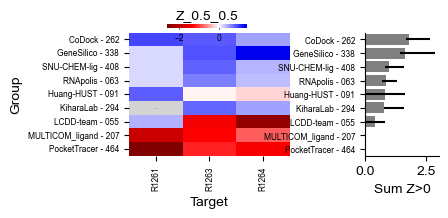

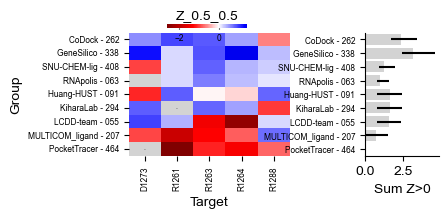

In [9]:
Z = 'Z_0.5_0.5'
ZTP =['R1261','R1263','R1264']
rank_order,g,ci = plot_heat_map(best1_df_ligand[best1_df_ligand.target.isin(ZTP)],Z,figsize=(4,2),
              savefig=f'figure_subpanels/CASP16_rna_ligand_just_ZTP_{Z}',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,num_bootstrap=1000)
_ = plot_heat_map(best1_df_ligand,Z,figsize=(4,2),
              savefig=f'figure_subpanels/CASP16_rna_ligand_all_5_{Z}',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
                h_bar_color='lightgrey',rank_order=rank_order,num_bootstrap=1000)


In [10]:
g['lower_bound'] = ci[0]
g['upper_bound'] = ci[1]
g.to_csv('summary_tables/final_Z_NA_ligand.csv')

## just some checking of best model to check out

In [8]:
scores[scores.target=='R1288'].sort_values('lddt_lp',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
68,68,34.0,R1288,338,R1288LG338_1,model_tmp.sdf,0.034825,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,9.492311,0.448326,5.208193,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,GeneSilico - 338
74,74,40.0,R1288,091,R1288LG091_4,model_tmp.sdf,0.018052,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,16.858477,0.426307,5.970347,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,Huang-HUST - 091
52,52,18.0,R1288,338,R1288LG338_4,model_tmp.sdf,0.076605,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,9.243393,0.418122,5.440455,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,GeneSilico - 338
44,44,10.0,R1288,091,R1288LG091_1,model_tmp.sdf,0.116593,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,8.688267,0.416801,6.163208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,Huang-HUST - 091
36,36,2.0,R1288,272,R1288LG272_1,model_tmp.sdf,0.133352,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,5.972159,0.414232,5.692958,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,GromihaLab - 272


In [9]:
scores[scores.target=='R1288'].sort_values('lddt_pli',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
34,34,0.0,R1288,408,R1288LG408_2,model_tmp.sdf,0.159967,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,4.788350,0.266185,8.577207,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,SNU-CHEM-lig - 408
35,35,1.0,R1288,063,R1288LG063_1,model_tmp.sdf,0.135575,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,11.247605,0.278773,6.145464,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,RNApolis - 063
36,36,2.0,R1288,272,R1288LG272_1,model_tmp.sdf,0.133352,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,5.972159,0.414232,5.692958,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,GromihaLab - 272
37,37,3.0,R1288,063,R1288LG063_3,model_tmp.sdf,0.132353,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,11.499922,0.302775,5.871224,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,RNApolis - 063
38,38,4.0,R1288,063,R1288LG063_5,model_tmp.sdf,0.131548,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,11.532496,0.288241,5.879421,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/R128...,NaN,NaN,NaN,RNApolis - 063


In [10]:
scores[scores.target=='D1273'].sort_values('lddt_lp',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
13,13,13.0,D1273,055,D1273LG055_4,model_tmp.sdf,0.116599,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,10.080626,0.419554,5.378673,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,LCDD-team - 055
16,16,16.0,D1273,055,D1273LG055_1,model_tmp.sdf,0.109908,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,10.202868,0.419554,5.378673,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,LCDD-team - 055
7,7,7.0,D1273,055,D1273LG055_5,model_tmp.sdf,0.139148,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,9.498469,0.419554,5.378673,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,LCDD-team - 055
9,9,9.0,D1273,055,D1273LG055_3,model_tmp.sdf,0.135685,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,9.359665,0.419554,5.378673,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,LCDD-team - 055
12,12,12.0,D1273,055,D1273LG055_2,model_tmp.sdf,0.118491,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,10.109751,0.419554,5.378673,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,LCDD-team - 055


In [11]:
scores[scores.target=='D1273'].sort_values('lddt_pli',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
0,0,0.0,D1273,338,D1273LG338_3,model_tmp.sdf,0.182770,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,5.832458,0.291972,6.921857,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,GeneSilico - 338
1,1,1.0,D1273,294,D1273LG294_4,model_tmp.sdf,0.163571,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,7.624604,0.313891,7.104760,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
2,2,2.0,D1273,294,D1273LG294_1,model_tmp.sdf,0.161367,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,9.253408,0.276949,7.384906,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
3,3,3.0,D1273,294,D1273LG294_2,model_tmp.sdf,0.154391,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,8.129498,0.365423,6.923060,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294
4,4,4.0,D1273,294,D1273LG294_3,model_tmp.sdf,0.153204,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,7.305310,0.291372,7.815579,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/D127...,NaN,NaN,NaN,KiharaLab - 294


In [17]:
scores[scores.target=='R1261'].sort_values('lddt_lp',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
100,100,19.0,R1261,262,R1261v1LG262_3,model_tmp.sdf,0.918208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.841061,0.912551,0.464291,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,CoDock - 262
98,98,17.0,R1261,262,R1261v1LG262_1,model_tmp.sdf,0.918208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.841061,0.912551,0.464291,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,CoDock - 262
91,91,10.0,R1261,091,R1261v1LG091_1,model_tmp.sdf,0.900466,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.792065,0.895699,0.541623,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,Huang-HUST - 091
92,92,11.0,R1261,091,R1261v1LG091_2,model_tmp.sdf,0.880208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,1.021843,0.895699,0.541623,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,Huang-HUST - 091
101,101,20.0,R1261,262,R1261v1LG262_4,model_tmp.sdf,0.868662,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.920638,0.877264,0.504743,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,CoDock - 262


In [16]:
scores[scores.target=='R1261'].sort_values('lddt_pli',ascending=False).head()

,level_0,index,target,group,model,model_ligand,lddt_pli,lddt_pli_coverage,lddt_pli_reference_ligand,lddt_pli_unassigned,rmsd,lddt_lp,bb_rmsd,rmsd_coverage,rmsd_reference_ligand,rmsd_unassigned,lddt_lp_dimer,lddt_pli_dimer,gr_code
98,98,17.0,R1261,262,R1261v1LG262_1,model_tmp.sdf,0.918208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.841061,0.912551,0.464291,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,CoDock - 262
100,100,19.0,R1261,262,R1261v1LG262_3,model_tmp.sdf,0.918208,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.841061,0.912551,0.464291,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,CoDock - 262
114,114,33.0,R1261,408,R1261v1LG408_2,model_tmp.sdf,0.901260,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,1.490254,0.765342,1.169749,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,SNU-CHEM-lig - 408
91,91,10.0,R1261,091,R1261v1LG091_1,model_tmp.sdf,0.900466,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,0.792065,0.895699,0.541623,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,Huang-HUST - 091
116,116,35.0,R1261,408,R1261v1LG408_4,model_tmp.sdf,0.897665,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,1.029942,0.765342,1.169749,1.0,/local/CASP16-orig/TARGETS/Targets_ligand/inci...,NaN,NaN,NaN,SNU-CHEM-lig - 408


In [ ]:
# check 63, 64 normalization 